# 01_Pipeline_Inferencia_16-CLASES_Codespaces

Pipeline de Inferencia en Streaming para 16-CLASES(Producción).
Extracción -> Limpieza Estática -> Predicción al Vuelo.

In [39]:
# ==========================================
# PIPELINE DE INFERENCIA EN STREAMING (PRODUCCIÓN)
# Extracción -> Limpieza Estática -> Predicción
# ==========================================
import os
import sys
print(sys.executable)
import subprocess
import time
import pandas as pd
import numpy as np
import scapy
import cicflowmeter
from pathlib import Path
#import joblib  # Para cargar el modelo ya entrenado
import importlib.metadata as md

import catboost
import lightgbm
import xgboost



# --- 1. CONFIGURACIÓN DE RUTAS ---
BASE_DIR = Path("/workspaces/CICFlowMeter-Pipeline_ProyectoAplicado_UNAD_ECDyA")
PCAP_PATH = BASE_DIR / "DoS-TCP_Flood10.pcap"
TMP_DIR = BASE_DIR / ".tmp_cicflowmeter"
RESULTS_FILE = BASE_DIR / "outputs" / "models"/ "predicciones_finales.csv"
MODEL_PATH = BASE_DIR / "outputs" / "models" / "CatBoostClassifier_02.pkl" 

TMP_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_FILE.parent.mkdir(parents=True, exist_ok=True)
if RESULTS_FILE.exists(): RESULTS_FILE.unlink()

print(f"✅ CatBoost: {catboost.__version__}")
print(f"✅ LightGBM: {lightgbm.__version__}")
print(f"✅ XGBoost: {xgboost.__version__}")

print(f"✅ NumPy version: {np.__version__}")
print(f"✅ ¿Tiene _core? {hasattr(np, '_core')}")

print("✅ pandas:", pd.__version__)
print("✅ scapy:", scapy.__version__)
print("✅ cicflowmeter:", md.version("cicflowmeter"))

/usr/local/bin/python
✅ CatBoost: 1.2.10
✅ LightGBM: 4.6.0
✅ XGBoost: 2.1.4
✅ NumPy version: 1.26.4
✅ ¿Tiene _core? True
✅ pandas: 2.2.0
✅ scapy: 2.4.3
✅ cicflowmeter: 0.1.6


In [12]:
# --- 2. MAPEO Y ORDEN ESTRICTO DEL MODELO ---
MAPEO = {
    'src_port':'Src Port', 'dst_port':'Dst Port', 'protocol':'Protocol',
    'flow_duration':'Flow Duration', 'tot_fwd_pkts':'Total Fwd Packet',
    'tot_bwd_pkts':'Total Bwd packets', 'totlen_fwd_pkts':'Total Length of Fwd Packet',
    'totlen_bwd_pkts':'Total Length of Bwd Packet', 'fwd_pkt_len_max':'Fwd Packet Length Max',
    'fwd_pkt_len_min':'Fwd Packet Length Min', 'fwd_pkt_len_std':'Fwd Packet Length Std',
    'bwd_pkt_len_min':'Bwd Packet Length Min', 'flow_byts_s':'Flow Bytes/s',
    'flow_pkts_s':'Flow Packets/s', 'flow_iat_mean':'Flow IAT Mean',
    'flow_iat_min':'Flow IAT Min', 'fwd_iat_tot':'Fwd IAT Total',
    'fwd_iat_min':'Fwd IAT Min', 'bwd_iat_tot':'Bwd IAT Total',
    'fwd_psh_flags':'Fwd PSH Flags', 'fwd_header_len':'Fwd Header Length',
    'bwd_pkts_s':'Bwd Packets/s', 'pkt_len_std':'Packet Length Std',
    'fin_flag_cnt':'FIN Flag Count', 'syn_flag_cnt':'SYN Flag Count',
    'rst_flag_cnt':'RST Flag Count', 'ack_flag_cnt':'ACK Flag Count',
    'urg_flag_cnt':'URG Flag Count', 'cwe_flag_count':'CWR Flag Count',
    'down_up_ratio':'Down/Up Ratio', 'fwd_byts_b_avg':'Fwd Bytes/Bulk Avg',
    'bwd_byts_b_avg':'Bwd Bytes/Bulk Avg', 'subflow_fwd_pkts':'Subflow Fwd Packets',
    'subflow_fwd_byts':'Subflow Fwd Bytes', 'subflow_bwd_pkts':'Subflow Bwd Packets',
    'init_fwd_win_byts':'FWD Init Win Bytes', 'init_bwd_win_byts':'Bwd Init Win Bytes',
    'fwd_act_data_pkts':'Fwd Act Data Pkts', 'active_mean':'Active Mean',
    'idle_std':'Idle Std'
}

# ORDEN EXACTO E INAMOVIBLE DEL MODELO
COLS_40 = [
    "Src Port", "Dst Port", "Protocol", "Flow Duration", "Total Fwd Packet", 
    "Total Bwd packets", "Total Length of Fwd Packet", "Total Length of Bwd Packet", 
    "Fwd Packet Length Max", "Fwd Packet Length Min", "Fwd Packet Length Std", 
    "Bwd Packet Length Min", "Flow Bytes/s", "Flow Packets/s", "Flow IAT Mean", 
    "Flow IAT Min", "Fwd IAT Total", "Fwd IAT Min", "Bwd IAT Total", "Fwd PSH Flags", 
    "Fwd Header Length", "Bwd Packets/s", "Packet Length Std", "FIN Flag Count", 
    "SYN Flag Count", "RST Flag Count", "ACK Flag Count", "URG Flag Count", 
    "CWR Flag Count", "Down/Up Ratio", "Fwd Bytes/Bulk Avg", "Bwd Bytes/Bulk Avg", 
    "Subflow Fwd Packets", "Subflow Fwd Bytes", "Subflow Bwd Packets", "FWD Init Win Bytes", 
    "Bwd Init Win Bytes", "Fwd Act Data Pkts", "Active Mean", "Idle Std"
]

# Definición para casteo seguro (memoria) sin alterar el orden del dataframe
COLS_INT32 = [
    "Src Port", "Dst Port", "Protocol", "Total Fwd Packet", "Total Bwd packets",
    "Fwd PSH Flags", "FIN Flag Count", "SYN Flag Count", "RST Flag Count",
    "ACK Flag Count", "URG Flag Count", "CWR Flag Count", 
    "Subflow Fwd Packets", "Subflow Bwd Packets", "Fwd Act Data Pkts"
]



In [33]:
# --- 3. CARGA DEL MODELO ---
import pickle

print(f"Cargando modelo desde {MODEL_PATH}...")

try:
    with open(MODEL_PATH, 'rb') as f:
        modelo = pickle.load(f)

    print("✅ Modelo CatBoostClassifier_02 16-Clases Cargado con pickle")
    print(f"Tipo: {type(modelo)}")
    
    # Validação segura das características
    if hasattr(modelo, "feature_names_"):
        # Usa APENAS o atributo correto do CatBoost
        features = modelo.feature_names_
        print(f"Número de Características: {len(features)}")
        print(f"Características: {features}")
        
    elif hasattr(modelo, "feature_names_in_"):
        # Caso futuramente você carregue um modelo diferente do scikit-learn
        features = modelo.feature_names_in_
        print(f"Número de Características: {len(features)}")
        print(f"Características: {features}")
        
    else:
        print("⚠️ No fue posible obtener los nombres de las características.")

except Exception as e:
    print(f"❌ Error al cargar: {e}")

Cargando modelo desde /workspaces/CICFlowMeter-Pipeline_ProyectoAplicado_UNAD_ECDyA/outputs/models/CatBoostClassifier_02.pkl...
✅ Modelo CatBoostClassifier_02 16-Clases Cargado con pickle
Tipo: <class 'catboost.core.CatBoostClassifier'>
Número de Características: 40
Características: ['Src Port', 'Dst Port', 'Protocol', 'Flow Duration', 'Total Fwd Packet', 'Total Bwd packets', 'Total Length of Fwd Packet', 'Total Length of Bwd Packet', 'Fwd Packet Length Max', 'Fwd Packet Length Min', 'Fwd Packet Length Std', 'Bwd Packet Length Min', 'Flow Bytes/s', 'Flow Packets/s', 'Flow IAT Mean', 'Flow IAT Min', 'Fwd IAT Total', 'Fwd IAT Min', 'Bwd IAT Total', 'Fwd PSH Flags', 'Fwd Header Length', 'Bwd Packets/s', 'Packet Length Std', 'FIN Flag Count', 'SYN Flag Count', 'RST Flag Count', 'ACK Flag Count', 'URG Flag Count', 'CWR Flag Count', 'Down/Up Ratio', 'Fwd Bytes/Bulk Avg', 'Bwd Bytes/Bulk Avg', 'Subflow Fwd Packets', 'Subflow Fwd Bytes', 'Subflow Bwd Packets', 'FWD Init Win Bytes', 'Bwd Init W

In [40]:
import shutil

print(shutil.which("tcpdump"))

/usr/bin/tcpdump


In [41]:
print(PCAP_PATH.exists())
print(PCAP_PATH)

True
/workspaces/CICFlowMeter-Pipeline_ProyectoAplicado_UNAD_ECDyA/DoS-TCP_Flood10.pcap


In [45]:
from scapy.all import rdpcap

try:
    pkts = rdpcap(str(PCAP_PATH), count=25)
    print(f"Leídos {len(pkts)} paquetes")
except Exception as e:
    print(type(e).__name__, e)

Leídos 25 paquetes


In [48]:
# --- 4. FRAGMENTACIÓN DEL PCAP ---
print(f"\n--- Iniciando segmentación de {PCAP_PATH.name} ---")
for f in TMP_DIR.glob("split_chunk_*"): f.unlink()

split_cmd = ["tcpdump", "-r", str(PCAP_PATH), "-C", "20", "-w", str(TMP_DIR / "split_chunk_")]
subprocess.run(split_cmd, stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)
chunks = sorted(list(TMP_DIR.glob("split_chunk_*")))

t_global = time.time()
filas_totales = 0




--- Iniciando segmentación de DoS-TCP_Flood10.pcap ---


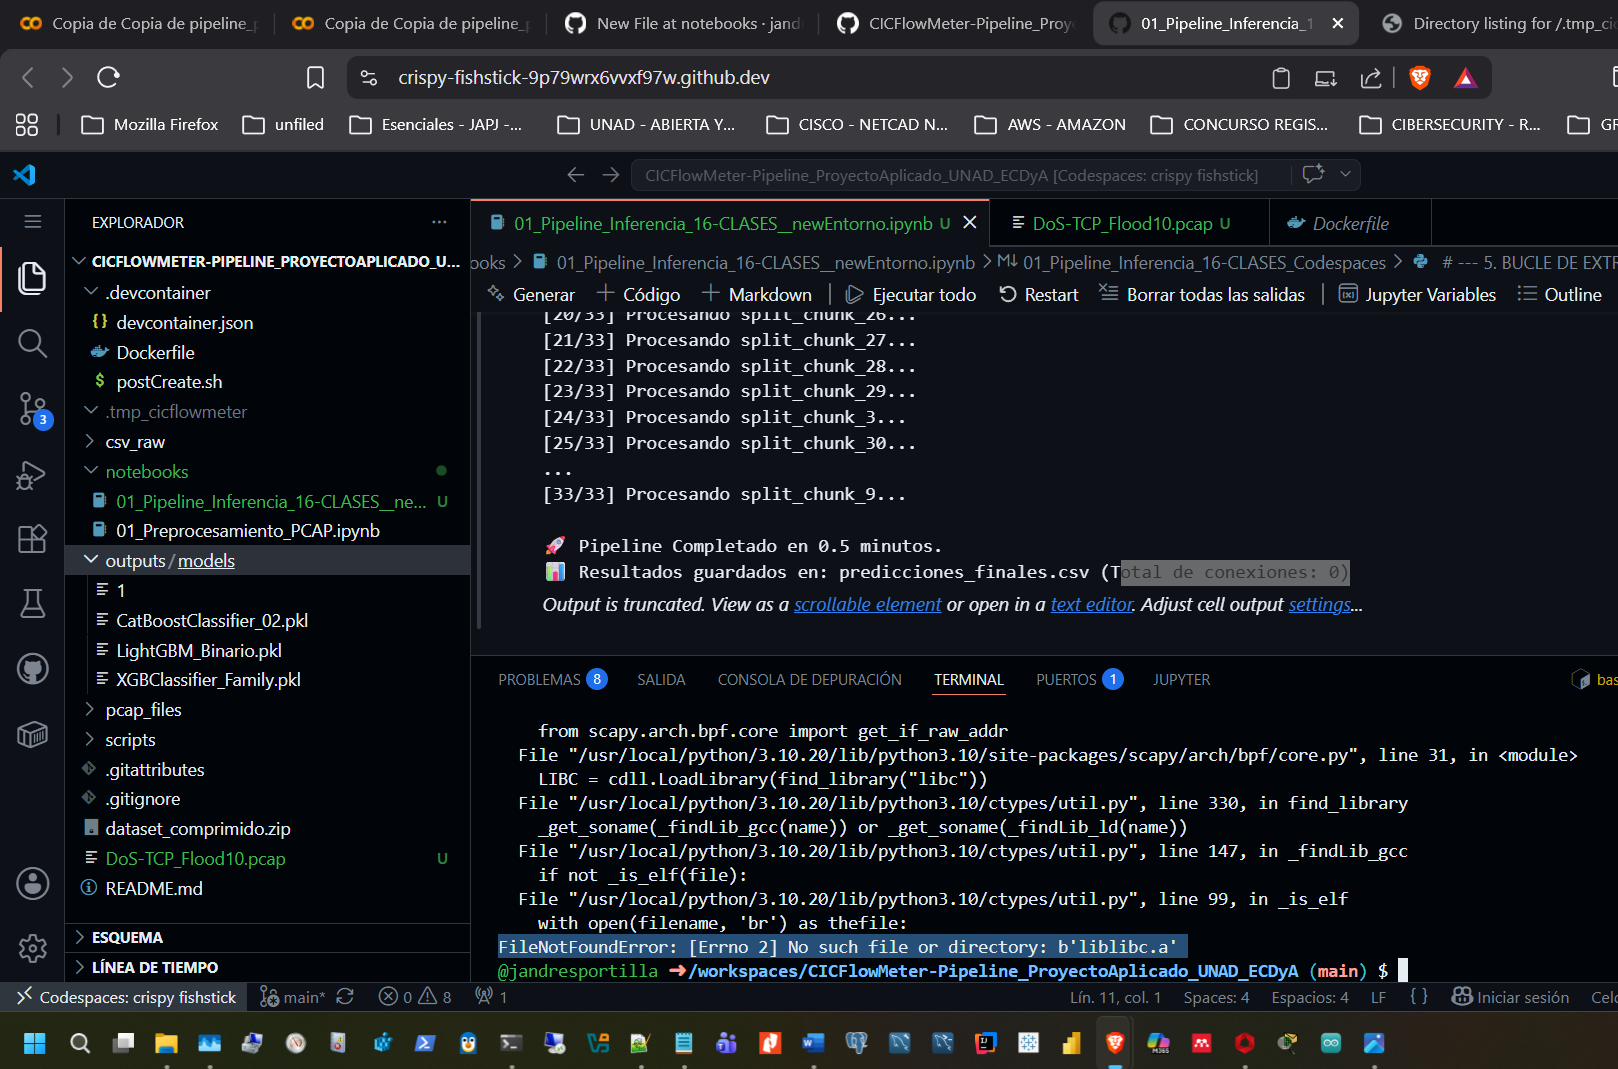

root@codespaces-c3a1b7:/workspaces/CICFlowMeter-Pipeline_ProyectoAplicado_UNAD_ECDyA# file DoS-TCP_Flood10.pcap
DoS-TCP_Flood10.pcap: pcap capture file, microsecond ts (little-endian) - version 2.4 (Ethernet, capture length 262144)

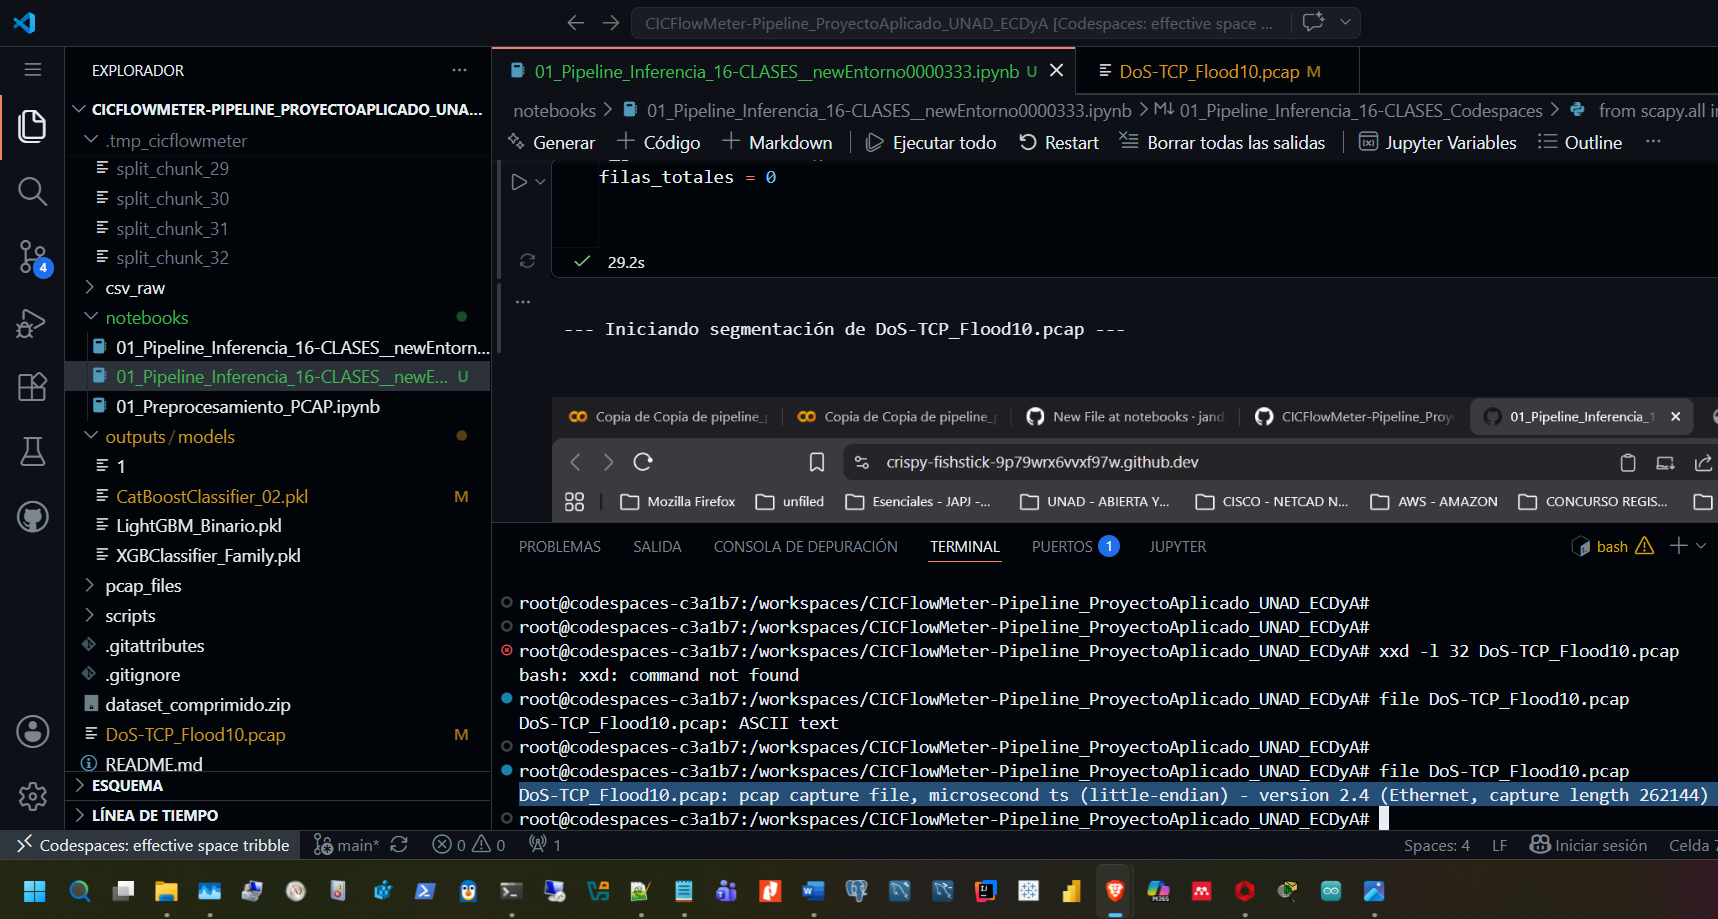

In [47]:
# --- DIAGNÓSTICO DE CICFLOWMETER ---
import subprocess
import os

# Probar con un chunk pequeño
chunks = sorted(list(TMP_DIR.glob("split_chunk_*")))
if chunks:
    test_chunk = chunks[0]
    test_csv = test_chunk.with_suffix(".csv")
    
    print(f"🔍 Probando cicflowmeter con: {test_chunk.name}")
    result = subprocess.run(
        ["cicflowmeter", "-f", str(test_chunk), "-c", str(test_csv)],
        capture_output=True,
        text=True
    )
    
    print(f"Return code: {result.returncode}")
    print(f"STDOUT: {result.stdout}")
    print(f"STDERR: {result.stderr}")
    
    if test_csv.exists():
        size = os.path.getsize(test_csv)
        print(f"CSV creado: {size} bytes")
        if size > 100:
            import pandas as pd
            df = pd.read_csv(test_csv)
            print(f"Filas: {len(df)}")
            print(f"Columnas: {df.columns.tolist()[:5]}...")
        else:
            print("⚠️ CSV vacío o muy pequeño")
    else:
        print("❌ No se creó el CSV")

🔍 Probando cicflowmeter con: split_chunk_
Return code: -15
STDOUT: Garbage Collection Began. Flows = 9984
Garbage Collection Finished. Flows = 9984
Garbage Collection Began. Flows = 19957
Garbage Collection Finished. Flows = 19957
Garbage Collection Began. Flows = 29946
Garbage Collection Finished. Flows = 29946
Garbage Collection Began. Flows = 39928
Garbage Collection Finished. Flows = 39928
Garbage Collection Began. Flows = 49879
Garbage Collection Finished. Flows = 49879
Garbage Collection Began. Flows = 59832
Garbage Collection Finished. Flows = 59832
Garbage Collection Began. Flows = 65609
Garbage Collection Finished. Flows = 65609
Garbage Collection Began. Flows = 65614
Garbage Collection Finished. Flows = 65614
Garbage Collection Began. Flows = 65620
Garbage Collection Finished. Flows = 65620
Garbage Collection Began. Flows = 65623
Garbage Collection Finished. Flows = 65623
Garbage Collection Began. Flows = 65632
Garbage Collection Finished. Flows = 65632
Garbage Collection Beg

In [49]:
# --- VERIFICAR EL PCAP ---
import subprocess


# Ver tamaño
import os
if os.path.exists(PCAP_PATH):
    size = os.path.getsize(PCAP_PATH) / 1024 / 1024
    print(f"✅ PCAP encontrado: {size:.2f} MB")
    
    # Ver paquetes
    result = subprocess.run(
        ["tcpdump", "-r", PCAP_PATH, "-c", "10"],
        capture_output=True,
        text=True
    )
    print(f"Primeros 10 paquetes:\n{result.stdout[:500]}")
else:
    print("❌ PCAP no encontrado")

✅ PCAP encontrado: 611.96 MB
Primeros 10 paquetes:
19:55:46.934353 IP 192.168.137.182.8966 > 192.168.137.221.https: Flags [none], win 512, length 0
19:55:46.934353 IP 192.168.137.182.8967 > 192.168.137.221.https: Flags [none], win 512, length 0
19:55:46.934353 IP 192.168.137.182.8968 > 192.168.137.221.https: Flags [none], win 512, length 0
19:55:46.934353 IP 192.168.137.182.8969 > 192.168.137.221.https: Flags [none], win 512, length 0
19:55:46.934353 IP 192.168.137.182.8970 > 192.168.137.221.https: Flags [none], win 512, length 0
19:55:46.934353


In [ ]:
# --- 5. BUCLE DE EXTRACCIÓN Y PREDICCIÓN AL VUELO ---
for idx, chunk in enumerate(chunks):
    t_chunk = time.time()
    chunk_csv = chunk.with_suffix(".csv")
    print(f"[{idx+1}/{len(chunks)}] Procesando {chunk.name}...")
    
    subprocess.run(["cicflowmeter", "-f", str(chunk), "-c", str(chunk_csv)], capture_output=True)
    
    if chunk_csv.exists() and chunk_csv.stat().st_size > 100:
        try:
            df_tmp = pd.read_csv(chunk_csv, low_memory=False)
            df_tmp.columns = df_tmp.columns.str.strip()
            
            df_renamed = pd.DataFrame()
            for k, v in MAPEO.items():
                if k in df_tmp.columns: df_renamed[v] = df_tmp[k].values
                
            # Rellenar faltantes si es necesario
            for col in COLS_40:
                if col not in df_renamed.columns:
                    df_renamed[col] = 0
                    
            # SE APLICA EL ORDEN ESTRICTO EXACTO
            df_opt = df_renamed[COLS_40].copy()
            
            # Limpieza Estática
            df_opt.replace([np.inf, -np.inf, "inf", "-inf", "Infinity", "-Infinity"], np.nan, inplace=True)
            df_opt.dropna(subset=["Flow Bytes/s", "Flow Packets/s"], inplace=True)
            
            if df_opt.empty:
                continue
                
            # Casteo Estricto de memoria (Se asegura el tipo por columna, sin mover su posición)
            for col in COLS_40:
                if col in COLS_INT32:
                    df_opt[col] = pd.to_numeric(df_opt[col], errors='coerce').fillna(0).astype(np.int32)
                else:
                    df_opt[col] = pd.to_numeric(df_opt[col], errors='coerce').fillna(0.0).astype(np.float32)


            # --- INFERENCIA GARANTIZADA EN ORDEN EXACTO ---
            # El dataframe df_opt entra al modelo exactamente en el orden COLS_40
            predicciones = modelo.predict(df_opt)
            df_opt['Prediccion_Modelo'] = predicciones
            
            # (Simulación visual mientras enlazas el modelo)
            #df_opt['Prediccion_Modelo'] = "Pendiente_Prediccion" 
            
            header = not RESULTS_FILE.exists()
            df_opt.to_csv(RESULTS_FILE, mode='a', index=False, header=header)
            
            filas_totales += len(df_opt)
            print(f"   ✅ OK: {len(df_opt)} flujos listos/clasificados. Tiempo: {time.time() - t_chunk:.1f}s")
            
        except Exception as e:
            print(f"   ❌ Error en {chunk_csv.name}: {e}")
            
    # Limpieza inmediata
    chunk.unlink()
    if chunk_csv.exists(): chunk_csv.unlink()

print(f"\n🚀 Pipeline Completado en {(time.time() - t_global) / 60:.1f} minutos.")
print(f"📊 Resultados guardados en: {RESULTS_FILE.name} (Total de conexiones: {filas_totales})")

[1/33] Procesando split_chunk_...
[2/33] Procesando split_chunk_1...
[3/33] Procesando split_chunk_10...
[4/33] Procesando split_chunk_11...
[5/33] Procesando split_chunk_12...
[6/33] Procesando split_chunk_13...
[7/33] Procesando split_chunk_14...
[8/33] Procesando split_chunk_15...
[9/33] Procesando split_chunk_16...
[10/33] Procesando split_chunk_17...
[11/33] Procesando split_chunk_18...
[12/33] Procesando split_chunk_19...
[13/33] Procesando split_chunk_2...
[14/33] Procesando split_chunk_20...
[15/33] Procesando split_chunk_21...
[16/33] Procesando split_chunk_22...
[17/33] Procesando split_chunk_23...


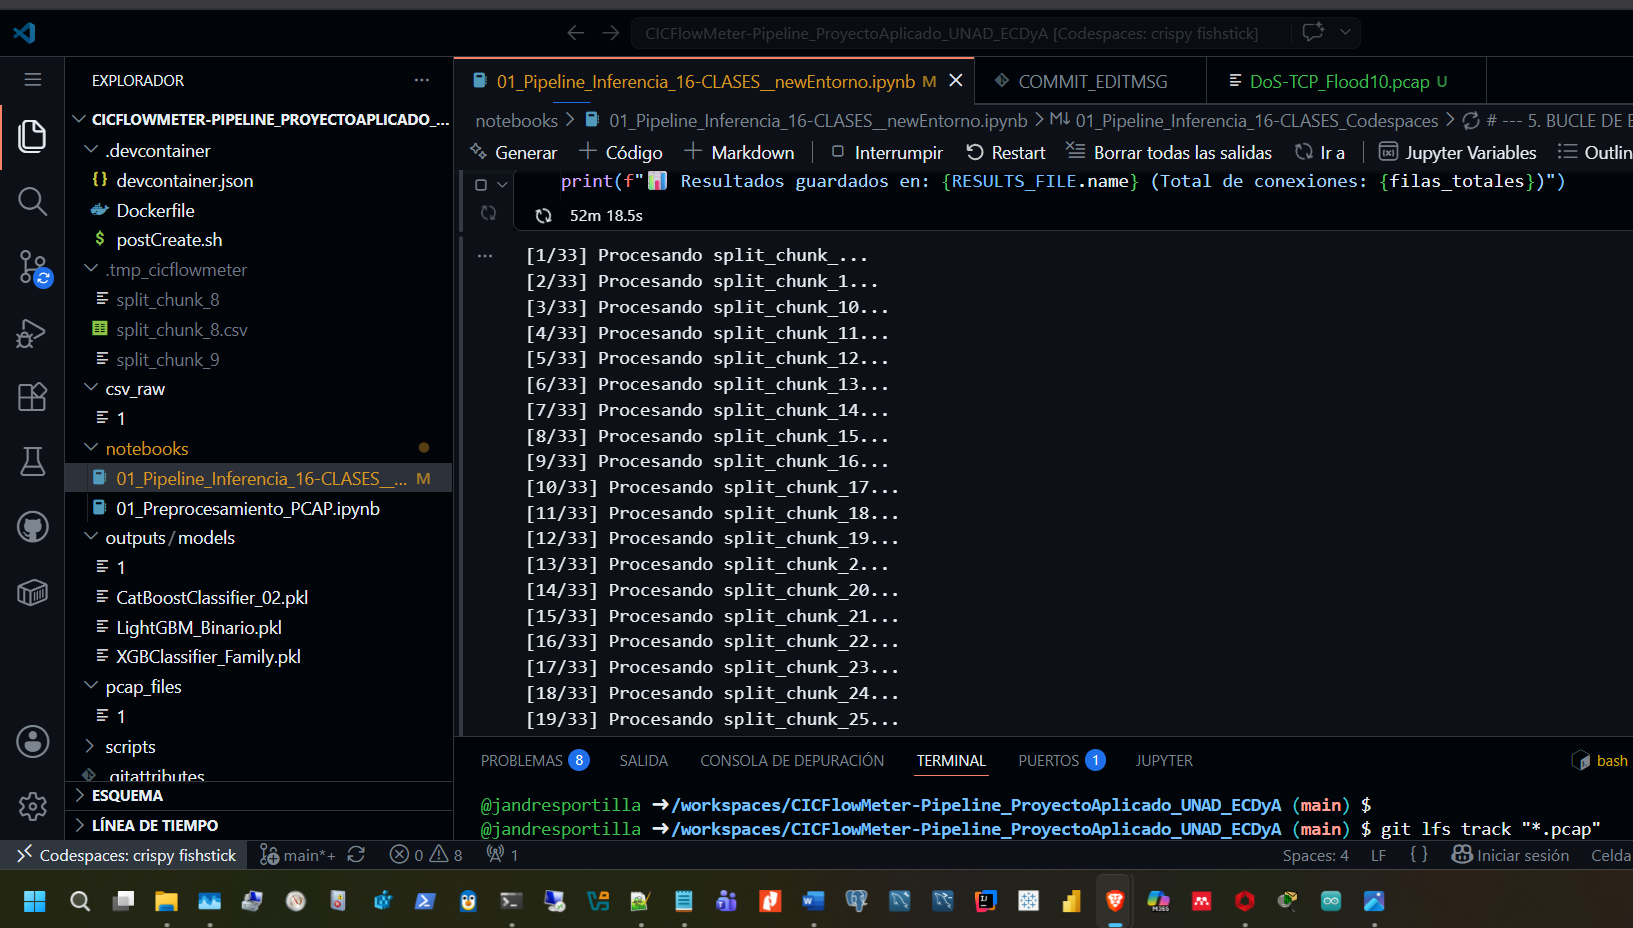

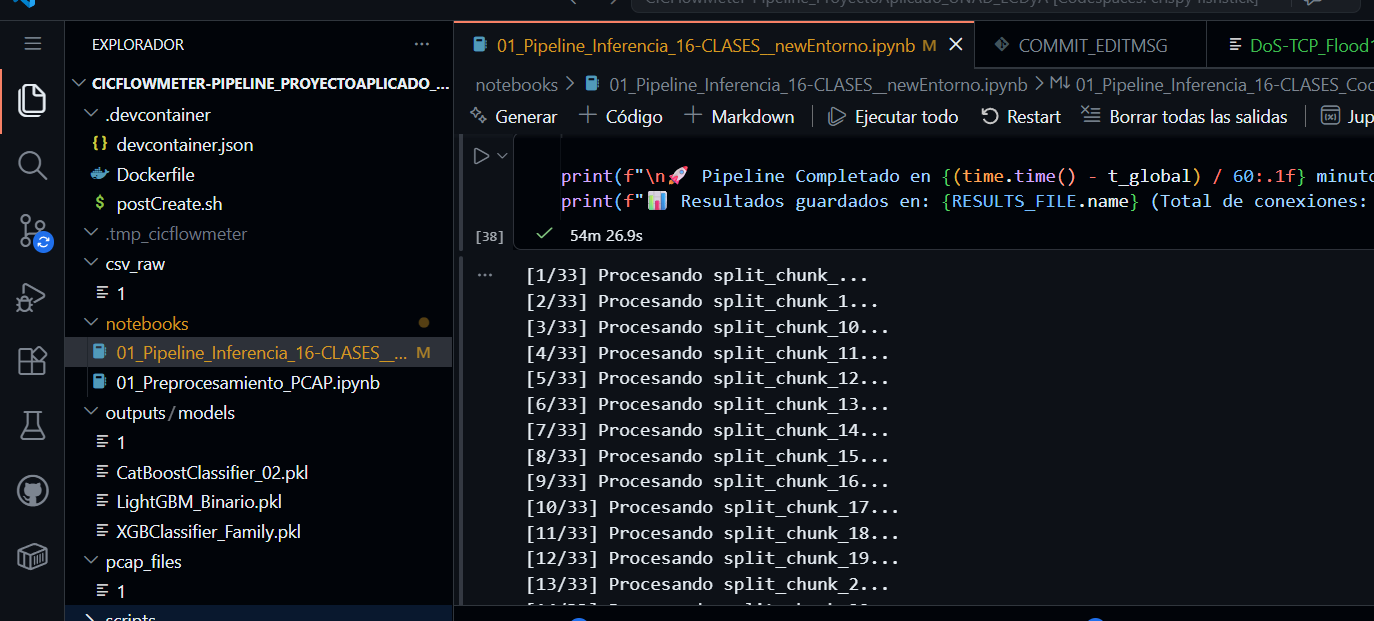

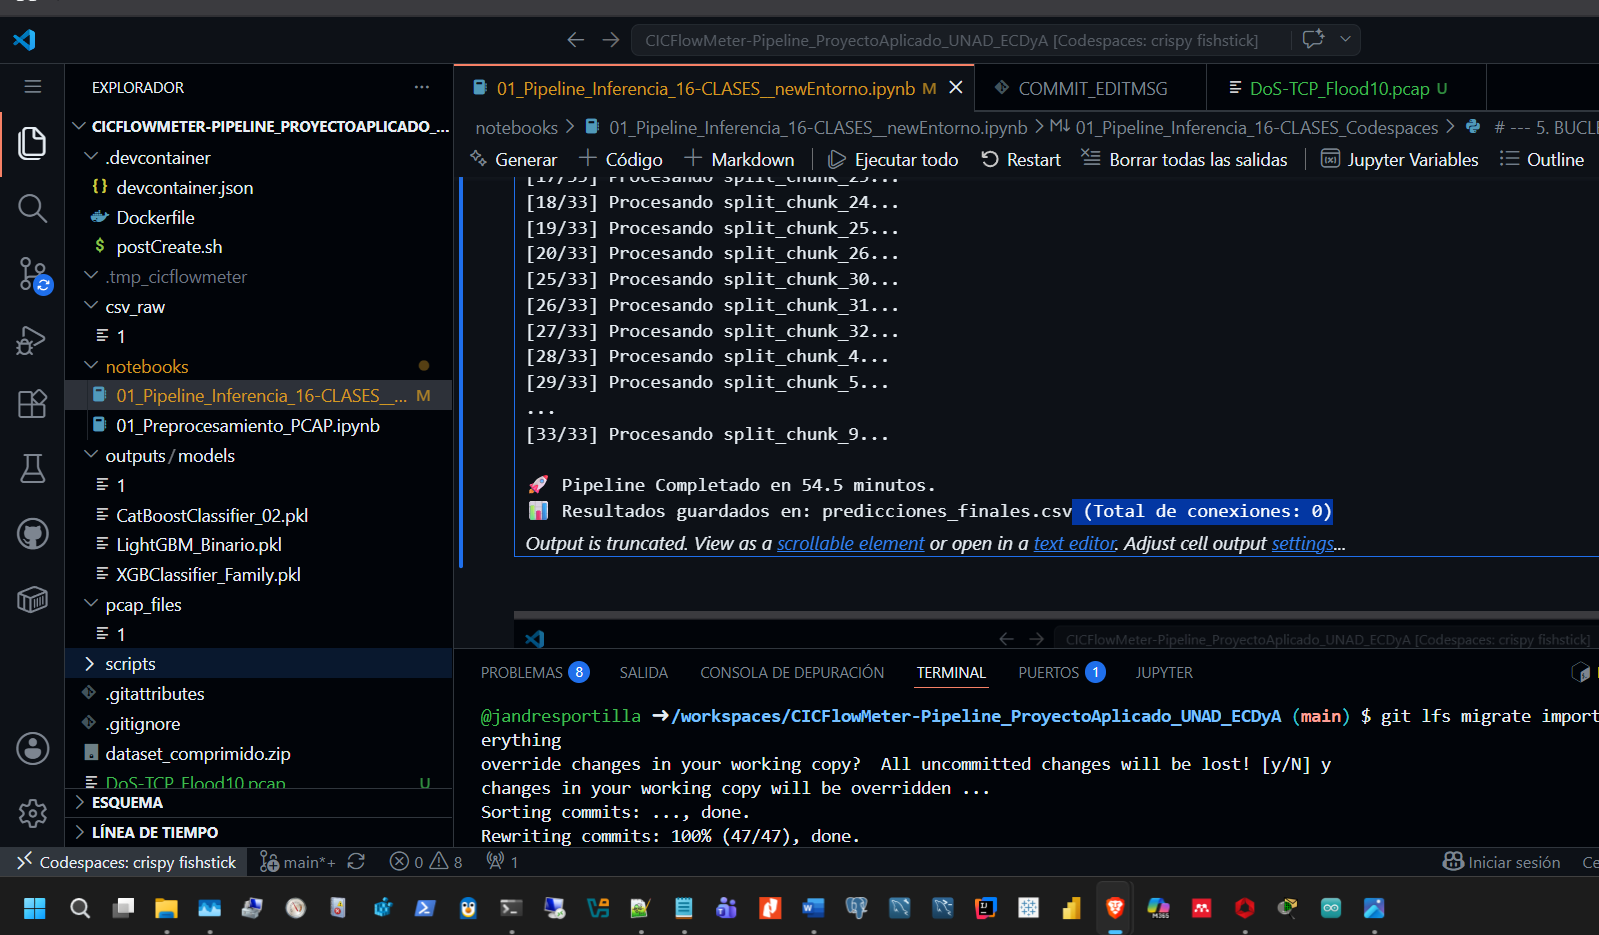

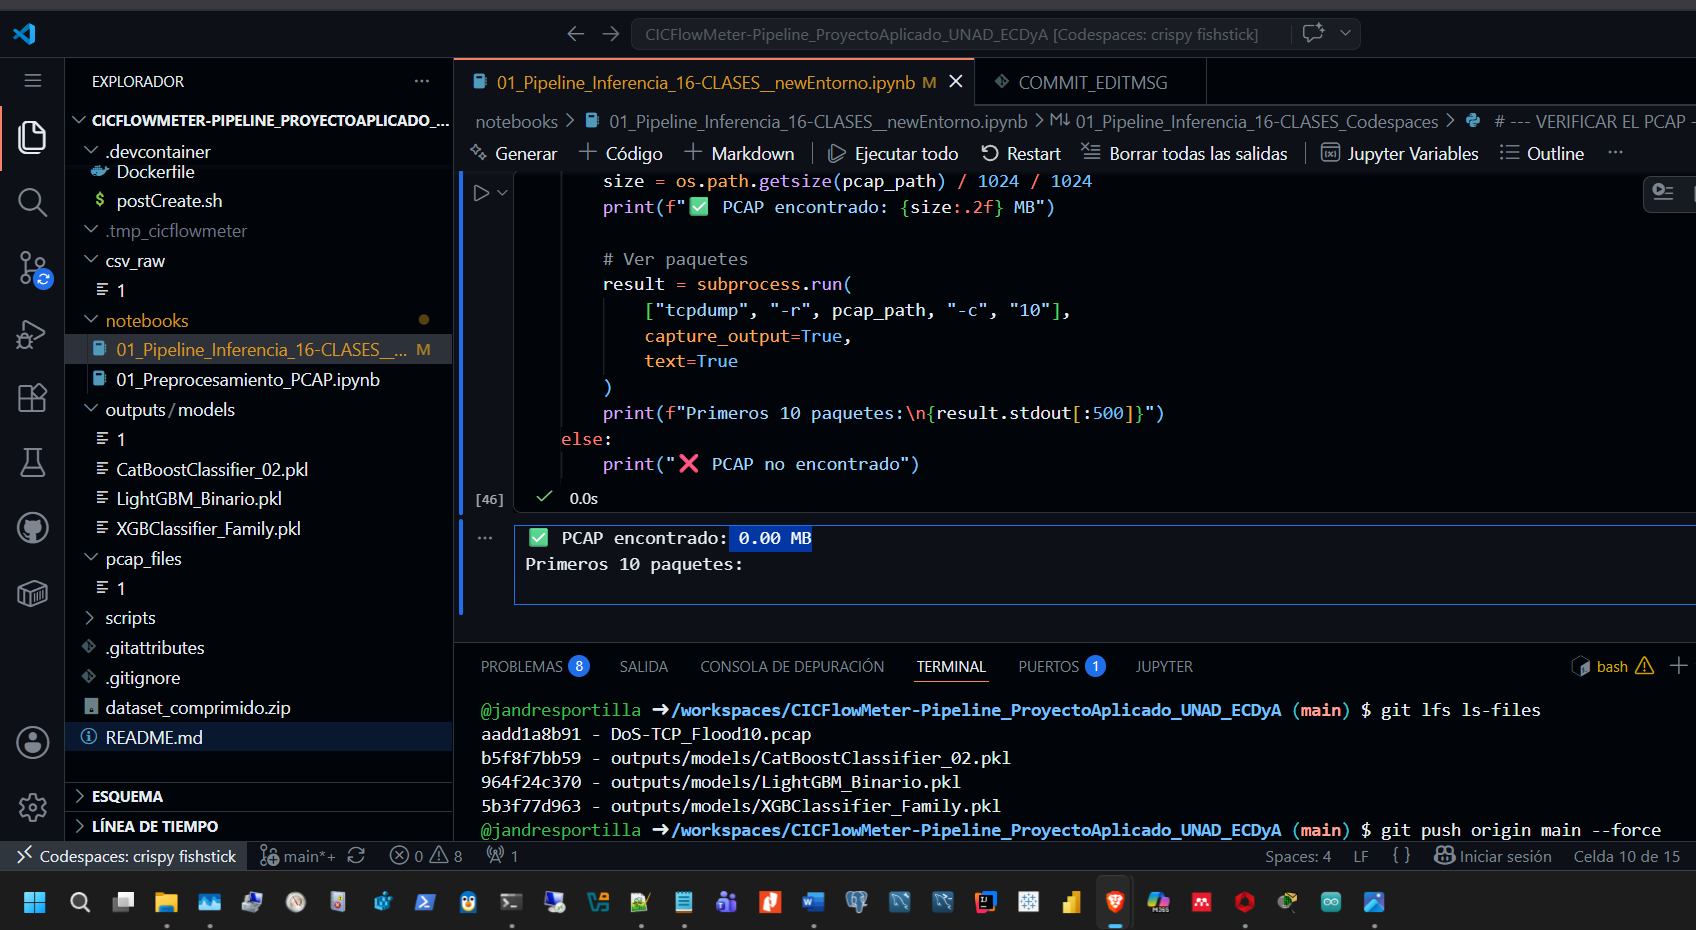

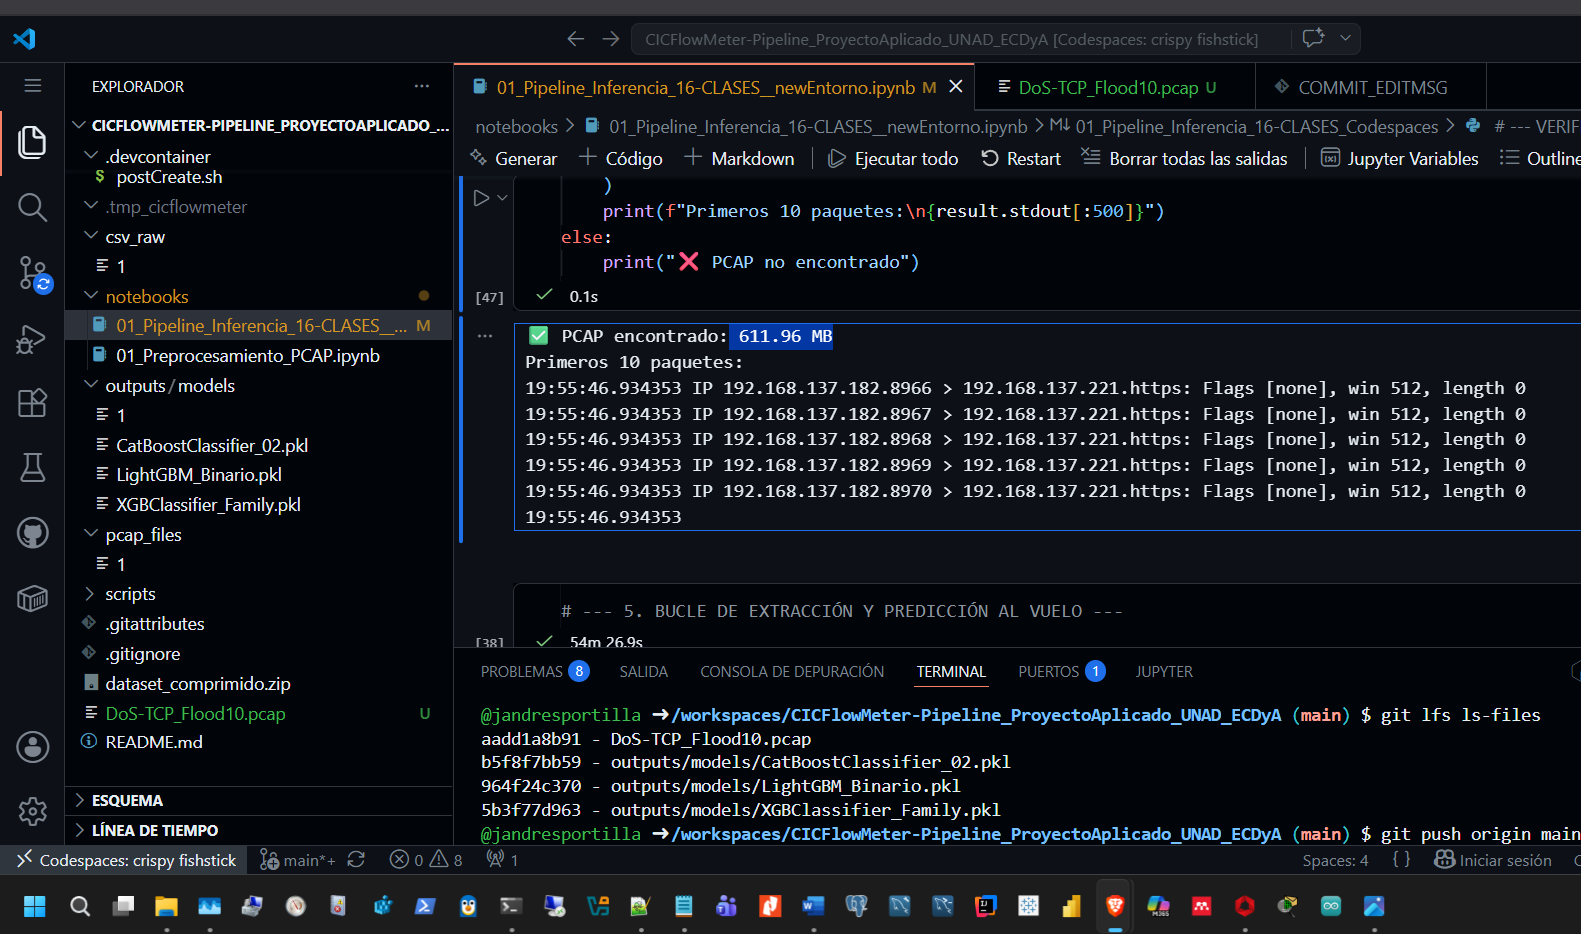

In [ ]:
# --- 5. BUCLE DE EXTRACCIÓN Y PREDICCIÓN AL VUELO ---
for idx, chunk in enumerate(chunks):
    t_chunk = time.time()
    chunk_csv = chunk.with_suffix(".csv")
    print(f"[{idx+1}/{len(chunks)}] Procesando {chunk.name}...")
    
    subprocess.run(["cicflowmeter", "-f", str(chunk), "-c", str(chunk_csv)], capture_output=True)
    
    if chunk_csv.exists() and chunk_csv.stat().st_size > 100:
        try:
            df_tmp = pd.read_csv(chunk_csv, low_memory=False)
            df_tmp.columns = df_tmp.columns.str.strip()
            
            df_renamed = pd.DataFrame()
            for k, v in MAPEO.items():
                if k in df_tmp.columns: df_renamed[v] = df_tmp[k].values
                
            # Rellenar faltantes si es necesario
            for col in COLS_40:
                if col not in df_renamed.columns:
                    df_renamed[col] = 0
                    
            # SE APLICA EL ORDEN ESTRICTO EXACTO
            df_opt = df_renamed[COLS_40].copy()
            
            # Limpieza Estática
            df_opt.replace([np.inf, -np.inf, "inf", "-inf", "Infinity", "-Infinity"], np.nan, inplace=True)
            df_opt.dropna(subset=["Flow Bytes/s", "Flow Packets/s"], inplace=True)
            
            if df_opt.empty:
                continue
                
            # Casteo Estricto de memoria (Se asegura el tipo por columna, sin mover su posición)
            for col in COLS_40:
                if col in COLS_INT32:
                    df_opt[col] = pd.to_numeric(df_opt[col], errors='coerce').fillna(0).astype(np.int32)
                else:
                    df_opt[col] = pd.to_numeric(df_opt[col], errors='coerce').fillna(0.0).astype(np.float32)


            # --- INFERENCIA GARANTIZADA EN ORDEN EXACTO ---
            # El dataframe df_opt entra al modelo exactamente en el orden COLS_40
            predicciones = modelo.predict(df_opt)
            df_opt['Prediccion_Modelo'] = predicciones
            
            # (Simulación visual mientras enlazas el modelo)
            #df_opt['Prediccion_Modelo'] = "Pendiente_Prediccion" 
            
            header = not RESULTS_FILE.exists()
            df_opt.to_csv(RESULTS_FILE, mode='a', index=False, header=header)
            
            filas_totales += len(df_opt)
            print(f"   ✅ OK: {len(df_opt)} flujos listos/clasificados. Tiempo: {time.time() - t_chunk:.1f}s")
            
        except Exception as e:
            print(f"   ❌ Error en {chunk_csv.name}: {e}")
            
    # Limpieza inmediata
    chunk.unlink()
    if chunk_csv.exists(): chunk_csv.unlink()

print(f"\n🚀 Pipeline Completado en {(time.time() - t_global) / 60:.1f} minutos.")
print(f"📊 Resultados guardados en: {RESULTS_FILE.name} (Total de conexiones: {filas_totales})")